# Milestone 1: Customer Complaint Monitoring

### Yonghun Kim
- Student ID: 685380031-8

### Yee Nwe Wynn
- Student ID: 695380018-1

### Yongjun Kim
- Student ID: 685380032-6

In [1]:
!pip install -q datasets pandas matplotlib

In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

dataset = load_dataset(
    "cardiffnlp/tweet_eval",
    "sentiment"
)

print(dataset)

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  901kB            

sentiment/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sentiment/validation-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


## 1. Exploratory Data Analysis

Exploratory Data Analysis was conducted to understand the structure, class distribution and quality of the TweetEval sentiment dataset. We examined dataset sizes, label mapping, sentiment distribution, missing values, duplicate tweets, sample tweets and tweet lengths.

### 1.1 Dataset Split Sizes

We examined the number of tweets in the training, validation and test sets.

In [3]:
split_sizes = {
    split: len(dataset[split])
    for split in dataset
}

split_size_df = pd.DataFrame(
    list(split_sizes.items()),
    columns=["Split", "Number of Tweets"]
)

split_size_df

,Split,Number of Tweets
0,train,45615
1,test,12284
2,validation,2000


### 6.2 Sentiment Label Mapping

In [4]:
label_names = dataset["train"].features["label"].names

for label_number, label_name in enumerate(label_names):
    print(f"{label_number} = {label_name}")

0 = negative
1 = neutral
2 = positive


In [5]:
train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print(train_df.head())

                                                text  label
0  "QT @user In the original draft of the 7th boo...      2
1  "Ben Smith / Smith (concussion) remains out of...      1
2  Sorry bout the stream last night I crashed out...      1
3  Chase Headley's RBI double in the 8th inning o...      1
4  @user Alciato: Bee will invest 150 million in ...      2


### 1.3 Sentiment Class Distribution

We counted the negative, neutral and positive tweets in each dataset split to identify possible class imbalance.

In [6]:
label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

train_df["sentiment"] = train_df["label"].map(label_map)
validation_df["sentiment"] = validation_df["label"].map(label_map)
test_df["sentiment"] = test_df["label"].map(label_map)

class_distribution = pd.DataFrame({
    "Train": train_df["sentiment"].value_counts(),
    "Validation": validation_df["sentiment"].value_counts(),
    "Test": test_df["sentiment"].value_counts()
})

class_distribution = class_distribution.reindex(
    ["Negative", "Neutral", "Positive"]
).fillna(0).astype(int)

class_distribution

class_percentage = (
    class_distribution
    .div(class_distribution.sum(axis=0), axis=1)
    .mul(100)
    .round(2)
)

class_percentage

,Train,Validation,Test
sentiment,,,
Negative,15.55,15.60,32.33
Neutral,45.32,43.45,48.33
Positive,39.13,40.95,19.33


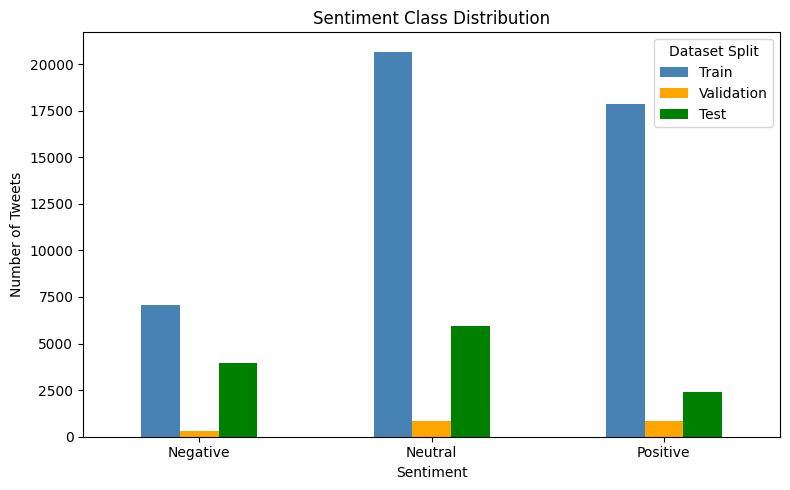

In [7]:
class_distribution.plot(
    kind="bar",
    figsize=(8, 5),
    color=["steelblue", "orange", "green"]
)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.legend(title="Dataset Split")
plt.tight_layout()
plt.show()

### 1.4 Data-Quality Checks

We checked each dataset split for missing text, empty tweets, missing labels and duplicate tweets.[link text](https://)

In [8]:
dataframes = {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df
}

quality_results = []

for split_name, df in dataframes.items():
    result = {
        "Split": split_name,
        "Missing Text": df["text"].isna().sum(),
        "Empty Text": df["text"].str.strip().eq("").sum(),
        "Missing Labels": df["label"].isna().sum(),
        "Duplicate Tweets": df["text"].duplicated().sum()
    }

    quality_results.append(result)

quality_df = pd.DataFrame(quality_results)

display(quality_df)


,Split,Missing Text,Empty Text,Missing Labels,Duplicate Tweets
0,Train,0,0,0,29
1,Validation,0,0,0,0
2,Test,0,0,0,0


In [9]:
duplicate_rows = train_df[
    train_df["text"].duplicated(keep=False)
].sort_values(
    ["text", "label"]
)

display(
    duplicate_rows[
        ["text", "label", "sentiment"]
    ].head(20)
)

,text,label,sentiment
12396,"""Charlie Rose with Bill Joy; Daniel Barenboim ...",1,Neutral
22568,"""Charlie Rose with Bill Joy; Daniel Barenboim ...",1,Neutral
338,"""Charlie Rose with Desmond Tutu; Bill Joy (Oct...",1,Neutral
19532,"""Charlie Rose with Desmond Tutu; Bill Joy (Oct...",1,Neutral
35017,"""Facebook may have solved mobile, but Google i...",1,Neutral
39410,"""Facebook may have solved mobile, but Google i...",1,Neutral
3170,"""I'm going to @user at US Bank Arena in Cincin...",1,Neutral
16312,"""I'm going to @user at US Bank Arena in Cincin...",1,Neutral
22917,"""More meta-textually, Ant-Man may be the worst...",0,Negative
40160,"""More meta-textually, Ant-Man may be the worst...",0,Negative


In [10]:
duplicate_label_counts = (
    duplicate_rows
    .groupby("text")["label"]
    .nunique()
)

conflicting_texts = duplicate_label_counts[
    duplicate_label_counts > 1
].index

print(
    "Duplicate texts with conflicting labels:",
    len(conflicting_texts)
)

conflicting_rows = train_df[
    train_df["text"].isin(conflicting_texts)
].sort_values(
    ["text", "label"]
)

display(
    conflicting_rows[
        ["text", "label", "sentiment"]
    ]
)

Duplicate texts with conflicting labels: 3


,text,label,sentiment
16929,An emotionally intelligent organisation throug...,1,Neutral
18334,An emotionally intelligent organisation throug...,2,Positive
43865,Buses to replace train services on Sunday as f...,1,Neutral
16293,Buses to replace train services on Sunday as f...,2,Positive
45079,Not making it to the main debate stage may not...,0,Negative
28331,Not making it to the main debate stage may not...,1,Neutral


### 1.5 Tweet-Length Analysis

Tweet length may influence model performance. We examined both the number of characters and the number of words in each training tweet.

In [11]:
train_df["character_count"] = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

train_df[
    ["character_count", "word_count"]
].describe()

,character_count,word_count
count,45615.000000,45615.000000
mean,106.932851,19.237444
std,26.251517,4.935990
min,10.000000,1.000000
25%,89.000000,16.000000
50%,113.000000,20.000000
75%,128.000000,23.000000
max,200.000000,35.000000


### 1.6 Sample Tweets

We inspected sample tweets from each sentiment class to understand the language and characteristics of the dataset.

In [12]:
for sentiment in ["Negative", "Neutral", "Positive"]:
    print(f"\n{sentiment.upper()} EXAMPLES")

    samples = train_df[
        train_df["sentiment"] == sentiment
    ]["text"].head(3)

    for tweet in samples:
        print("-", tweet)


NEGATIVE EXAMPLES
- So disappointed in wwe summerslam! I want to see john cena wins his 16th title
- That sucks if you have to take the SATs tomorrow
- Amy Schumer sat down with The Hollywood Reporter and opened up about the sexist remarks and unnecessary criticism she's faced since

NEUTRAL EXAMPLES
- "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
- Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.
- Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays

POSITIVE EXAMPLES
- "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
- @user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"
- @user LIT MY MUM 'Kerry the louboutins I wonder how many Willam owns!!! Look Kerr

### 1.7 Initial EDA Findings

- TweetEval contains 59,899 tweets: 45,615 for training, 2,000 for validation and 12,284 for testing.
- Neutral is the largest class in all three dataset splits.
- Negative tweets make up about 15.6% of the training and validation sets, but 32.34% of the test set.
- Therefore, the class distribution of the test set is different from the training and validation sets.
- No missing text, empty tweets or missing labels were found.
- The training set contains 29 duplicate occurrences. Three duplicated text groups have conflicting labels.
- A training tweet contains about 19 words on average. Tweet lengths range from 1 to 35 words.
- We will use per-class precision, recall and F1-score because accuracy alone may hide weak performance for a specific sentiment class.
- Tweet length will also be used as metadata to check whether the models perform differently on short and long tweets.

## 2. Data Cleaning and Preparation

The TweetEval dataset was inspected before making any cleaning decisions. Because it is an established benchmark dataset, the original text and official dataset splits were preserved.

Emojis, hashtags, punctuation and negation words were retained because they may contain useful sentiment information. The original text was preserved in a separate column, and any necessary preparation will be applied to a processed-text column.

In [13]:
for df in [train_df, validation_df, test_df]:
    df["original_text"] = df["text"]
    df["processed_text"] = df["text"]

In [14]:
preparation_checks = []

for split_name, df in dataframes.items():
    preparation_checks.append({
        "Split": split_name,
        "Contains @user": df["text"].str.contains(
            "@user",
            regex=False
        ).sum(),
        "Contains http": df["text"].str.contains(
            "http",
            case=False,
            regex=False
        ).sum(),
        "Contains hashtag": df["text"].str.contains(
            "#",
            regex=False
        ).sum()
    })

preparation_check_df = pd.DataFrame(preparation_checks)
preparation_check_df

,Split,Contains @user,Contains http,Contains hashtag
0,Train,13157,89,8567
1,Validation,610,3,356
2,Test,4848,377,4833


### 2.1 Data-Cleaning Decision

No missing text, empty tweets or missing labels were found. The training set contains 29 duplicate occurrences, including three duplicated texts with conflicting labels. These records were retained to preserve the official TweetEval dataset, but the conflicts were noted as a data-quality limitation.

No extensive cleaning was required. Emojis, hashtags, punctuation, `@user`, `http` and negation words were retained because they may help sentiment classification. The original text and official dataset splits were preserved, and each model will use its own tokenizer.

## 3. Provided Baseline Model Exploration

We explore two baseline models to effectively perform performance evaluation for new candidate models and baseline models based on the "Ready to Ship" criteria and evaluations through metrics our team haved selected.

In this section - Provided Baseline Model Exploration.
We explore
1. Twitter-roBERTa-base for Sentiment Analysis: RoBERTa-base model trained with over 124 million tweets and finetuned with TweetEval benchmark.
2. gpt2-finetuning-model-3000-samples: gpt2 finetuned on the imdb dataset.

gpt2-finetuning-model-3000-samples model was originally trained for binary classification tasks. Therefore, it does not fit in our multi-class classification situation. In this case, we only use negative and positive without neutral to enable this model to perform.


### Twitter-roBERTa-base for Sentiment Analysis Code Exploration

In [15]:
import torch
import numpy as np
import time
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer

tokenizer_twitter = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
model_twitter = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest", device_map="auto")

tokenizer_twitter.pad_token = tokenizer_twitter.eos_token
model_twitter.config.pad_token_id = model_twitter.config.eos_token_id

def tokenize_twitter(ex):
  return tokenizer_twitter(ex["text"], padding="max_length", truncation=True, max_length=128)

tokenized_test_twitter = dataset["test"].map(tokenize_twitter, batched=True)

trainer_twitter = Trainer(model=model_twitter)
if torch.cuda.is_available():
  torch.cuda.synchronize()
start_time = time.perf_counter()
output_twitter = trainer_twitter.predict(tokenized_test_twitter)
if torch.cuda.is_available():
  torch.cuda.synchronize()
prediction_time_twitter = time.perf_counter() - start_time


logits_twitter = torch.tensor(output_twitter.predictions)
probs_twitter = torch.nn.functional.softmax(logits_twitter, dim=-1)
confs_twitter, preds_twitter = torch.max(probs_twitter, dim=-1)

predictions_twitter = preds_twitter.numpy()
confidences_twitter = confs_twitter.numpy()


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

### GPT2-finetuning-model-3000-samples Code Exploration

In [16]:
tokenizer_gpt2 = AutoTokenizer.from_pretrained("LYTinn/gpt2-finetuning-sentiment-model-3000-samples")
model_gpt2 = AutoModelForSequenceClassification.from_pretrained("LYTinn/gpt2-finetuning-sentiment-model-3000-samples", device_map="auto")

if tokenizer_gpt2.pad_token_id is None:
  if tokenizer_gpt2.eos_token_id is not None:
    tokenizer_gpt2.pad_token = tokenizer_gpt2.eos_token
  else:
    tokenizer_gpt2.add_special_tokens({"pad_token": "[PAD]"})
    model_gpt2.resize_token_embeddings(len(tokenizer_gpt2))

model_gpt2.config.pad_token_id = tokenizer_gpt2.pad_token_id

test_gpt2 = dataset["test"].filter(lambda ex: ex["label"] != 1)
test_gpt2 = test_gpt2.map(lambda ex: {"label": 0 if ex["label"] == 0 else 1})

def tokenize_gpt2(ex):
  return tokenizer_gpt2(ex["text"], padding="max_length", truncation=True, max_length=128)

tokenized_test_gpt2 = test_gpt2.map(tokenize_gpt2, batched=True)

trainer_gpt2 = Trainer(model=model_gpt2)
trainer_twitter = Trainer(model=model_twitter)
if torch.cuda.is_available():
  torch.cuda.synchronize()
start_time = time.perf_counter()
output_gpt2 = trainer_gpt2.predict(tokenized_test_gpt2)
if torch.cuda.is_available():
  torch.cuda.synchronize()
prediction_time_gpt2 = time.perf_counter() - start_time

logits_gpt2 = torch.tensor(output_gpt2.predictions)
probs_gpt2 = torch.nn.functional.softmax(logits_gpt2, dim=-1)
confs_gpt2, preds_gpt2 = torch.max(probs_gpt2, dim=-1)

predictions_gpt2 = preds_gpt2.numpy()
confidences_gpt2 = confs_gpt2.numpy()


config.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/360 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

Filter:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/6347 [00:00<?, ? examples/s]

Map:   0%|          | 0/6347 [00:00<?, ? examples/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  510MB            

model.safetensors: downloading bytes:           |  0.00B            

#### Printing final prediction table

In [17]:
pred_table = test_df.copy()

pred_table["roberta_pred"] = predictions_twitter
pred_table["roberta_conf"] = confidences_twitter
pred_table["roberta_sentiment"] = pred_table["roberta_pred"].map({
    0: "Negative",
    1: "Neutral",
    2: "Positive"
})

pred_table["gpt2_pred"] = np.nan
pred_table["gpt2_conf"] = np.nan
pred_table["gpt2_sentiment"] = "Not evaluated"

binary_mask = pred_table["label"] != 1

pred_table.loc[binary_mask, "gpt2_pred"] = predictions_gpt2
pred_table.loc[binary_mask, "gpt2_conf"] = confidences_gpt2
pred_table.loc[binary_mask, "gpt2_sentiment"] = [
    "Negative" if pred == 0 else "Positive"
    for pred in predictions_gpt2
]

final_table = pred_table[[
    "original_text",
    "sentiment",
    "roberta_sentiment",
    "roberta_conf",
    "gpt2_sentiment",
    "gpt2_conf"
]]

display(final_table.head())

,original_text,sentiment,roberta_sentiment,roberta_conf,gpt2_sentiment,gpt2_conf
0,@user @user what do these '1/2 naked pics' hav...,Neutral,Negative,0.804725,Not evaluated,NaN
1,OH: “I had a blue penis while I was this” [pla...,Neutral,Neutral,0.866949,Not evaluated,NaN
2,"@user @user That's coming, but I think the vic...",Neutral,Neutral,0.763725,Not evaluated,NaN
3,I think I may be finally in with the in crowd ...,Positive,Positive,0.774047,Positive,0.782225
4,"@user Wow,first Hugo Chavez and now Fidel Cast...",Negative,Neutral,0.416397,Positive,0.999927


## 4. Candidate Model Selection

### BERTweet

In [18]:
tokenizer_bertweet = AutoTokenizer.from_pretrained("finiteautomata/bertweet-base-sentiment-analysis")
model_bertweet = AutoModelForSequenceClassification.from_pretrained("finiteautomata/bertweet-base-sentiment-analysis", device_map="auto")

def tokenize_bertweet(ex):
  return tokenizer_bertweet(ex["text"], padding="max_length", truncation=True, max_length=128)

tokenized_test_bertweet = dataset["test"].map(tokenize_bertweet, batched=True)

prediction_test_bertweet = tokenized_test_bertweet.remove_columns("label")

trainer_bertweet = Trainer(model=model_bertweet)

if torch.cuda.is_available():
  torch.cuda.synchronize()
start_time = time.perf_counter()
output_bertweet = trainer_bertweet.predict(prediction_test_bertweet)
if torch.cuda.is_available():
  torch.cuda.synchronize()
prediction_time_bertweet = time.perf_counter() - start_time

logits_bertweet = torch.tensor(output_bertweet.predictions)
probs_bertweet = torch.nn.functional.softmax(logits_bertweet, dim=-1)
confs_bertweet, preds_bertweet = torch.max(probs_bertweet, dim=-1)

predictions_bertweet = preds_bertweet.numpy()
confidences_bertweet = confs_bertweet.numpy()

bertweet_sentiments = [
  "Negative" if pred == 0 else "Neutral" if pred == 1 else "Positive"
  for pred in predictions_bertweet
]

config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/338 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  540MB            

model.safetensors: downloading bytes:           |  0.00B            

### DistilBERT

In [19]:
tokenizer_distilbert = AutoTokenizer.from_pretrained("lxyuan/distilbert-base-multilingual-cased-sentiments-student")
model_distilbert = AutoModelForSequenceClassification.from_pretrained("lxyuan/distilbert-base-multilingual-cased-sentiments-student", device_map="auto")

def tokenize_distilbert(ex):
  return tokenizer_distilbert(ex["text"], padding="max_length", truncation=True, max_length=128)

tokenized_test_distilbert = dataset["test"].map(tokenize_distilbert, batched=True)

prediction_test_distilbert = tokenized_test_distilbert.remove_columns("label")

trainer_distilbert = Trainer(model=model_distilbert)

if torch.cuda.is_available():
  torch.cuda.synchronize()
start_time = time.perf_counter()
output_distilbert = trainer_distilbert.predict(prediction_test_distilbert)
if torch.cuda.is_available():
  torch.cuda.synchronize()
prediction_time_distilbert = time.perf_counter() - start_time

logits_distilbert = torch.tensor(output_distilbert.predictions)
probs_distilbert = torch.nn.functional.softmax(logits_distilbert, dim=-1)
confs_distilbert, preds_distilbert = torch.max(probs_distilbert, dim=-1)

predictions_distilbert_raw = preds_distilbert.numpy()
confidences_distilbert = confs_distilbert.numpy()

predictions_distilbert = np.array([
  2 if pred == 0 else 1 if pred == 1 else 0
  for pred in predictions_distilbert_raw
])

distilbert_sentiments = [
  "Negative" if pred == 0 else "Neutral" if pred == 1 else "Positive"
  for pred in predictions_distilbert
]

config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  541MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

In [20]:
pred_table_2 = test_df.copy()

pred_table_2["bertweet_pred"] = predictions_bertweet
pred_table_2["bertweet_conf"] = confidences_bertweet
pred_table_2["bertweet_sentiment"] = bertweet_sentiments

pred_table_2["distilbert_pred"] = predictions_distilbert
pred_table_2["distilbert_conf"] = confidences_distilbert
pred_table_2["distilbert_sentiment"] = distilbert_sentiments

final_table_2 = pred_table_2[[
  "original_text",
  "sentiment",
  "bertweet_sentiment",
  "bertweet_conf",
  "distilbert_sentiment",
  "distilbert_conf"
]]

display(final_table_2.head())

,original_text,sentiment,bertweet_sentiment,bertweet_conf,distilbert_sentiment,distilbert_conf
0,@user @user what do these '1/2 naked pics' hav...,Neutral,Negative,0.812552,Negative,0.485530
1,OH: “I had a blue penis while I was this” [pla...,Neutral,Neutral,0.956738,Positive,0.459844
2,"@user @user That's coming, but I think the vic...",Neutral,Negative,0.659974,Negative,0.505607
3,I think I may be finally in with the in crowd ...,Positive,Positive,0.826933,Positive,0.501493
4,"@user Wow,first Hugo Chavez and now Fidel Cast...",Negative,Neutral,0.529640,Positive,0.620723


## 5. Evaluation Metrics

To evaluate the candidate models and baseline models, we apply metrics as follows:

1. F1-score - Macro, Positive, Negative, Neutral
2. Accuracy
3. Precision - Positive, Negative, Neutral
4. Recall - Positive, Negative, Neutral
5. Confusion Matrix
6. Training speed

### Purpose and use of each evaluation metrics

1. F1-score: This metric is calculated by combining precision and recall. Thus, to achieve high F1-score, both precision and recall should be evenly high.
We use Macro, Positive, Negative, and Neutral to inspect our model's performance in different aspects. Macro F1 for overall, positive F1 for focused view on positive predictions, negative F1 for focused view on negatitve predictions, neutral F1 for focused view on neutral predictions.

2. Accuracy: Accuracy is used to inspect how much the model predicted correctly among the whole data.

3. Precision: Precision is calculated for positive, negative, and neutral.
Precision refers to ratio of actual positives among all predicted positives.
This applies the same to negative and neutral.

4. Recall: Recall is also calculated for all positive, negative, and neutral.
This indicates how many cases were predicted positive among actual positive data. This applies the same to negative and neutral.

5. Confusion Matrix: Confusion matrix is a cross table indicating correct predictions and incorrect predictions.
Confusion matrix will include:
PREDICTED - positive, negative, neutral /
ACTUAL - positive, negative, neutral - **Total: 6.**

6. Prediction Speed: Number of posts and comments on the internet is rapidly rising. Fast prediction speed is important to follow the trend and ultimately to reflect user's needs and gain useful feedbacks from customers.
By improving the prediction speed, models could be more suitable to follow rapidly changing environment.
By evaluating the speed, we expect to inspect and compare which model is more suitable in the perspective of swiftness.
To inspect in various perspectives, we used Total prediction time (How long it took to handle for the whole data), Available examples per second (How many samples can be handled in a second), and Average time cost per example (How long it took to handle for one example - millisecond).

,Model,Evaluation Scope,Number of Examples,Accuracy,Macro F1,Negative F1,Neutral F1,Positive F1,Negative Precision,Neutral Precision,Positive Precision,Negative Recall,Neutral Recall,Positive Recall,Total prediction time (seconds),Available examples per second,Avg time cost per example (milliseconds)
0,RoBERTa,Negative + Neutral + Positive,12284,0.7218,0.7240,0.7435,0.7036,0.7251,0.6895,0.7566,0.7101,0.8066,0.6576,0.7406,27.2970,450.0121,2.2222
1,GPT-2,Negative + Positive only,6347,0.5360,0.5261,0.5946,NaN,0.4575,0.6559,NaN,0.4067,0.5438,NaN,0.5229,13.1560,482.4406,2.0728
2,BERTweet,Negative + Neutral + Positive,12284,0.7207,0.7207,0.7482,0.7053,0.7087,0.7076,0.7461,0.6901,0.7938,0.6687,0.7284,25.0629,490.1278,2.0403
3,DistilBERT,Negative + Neutral + Positive,12284,0.4359,0.3935,0.6336,0.0612,0.4858,0.5316,0.5202,0.3382,0.7842,0.0325,0.8619,14.4663,849.1464,1.1777


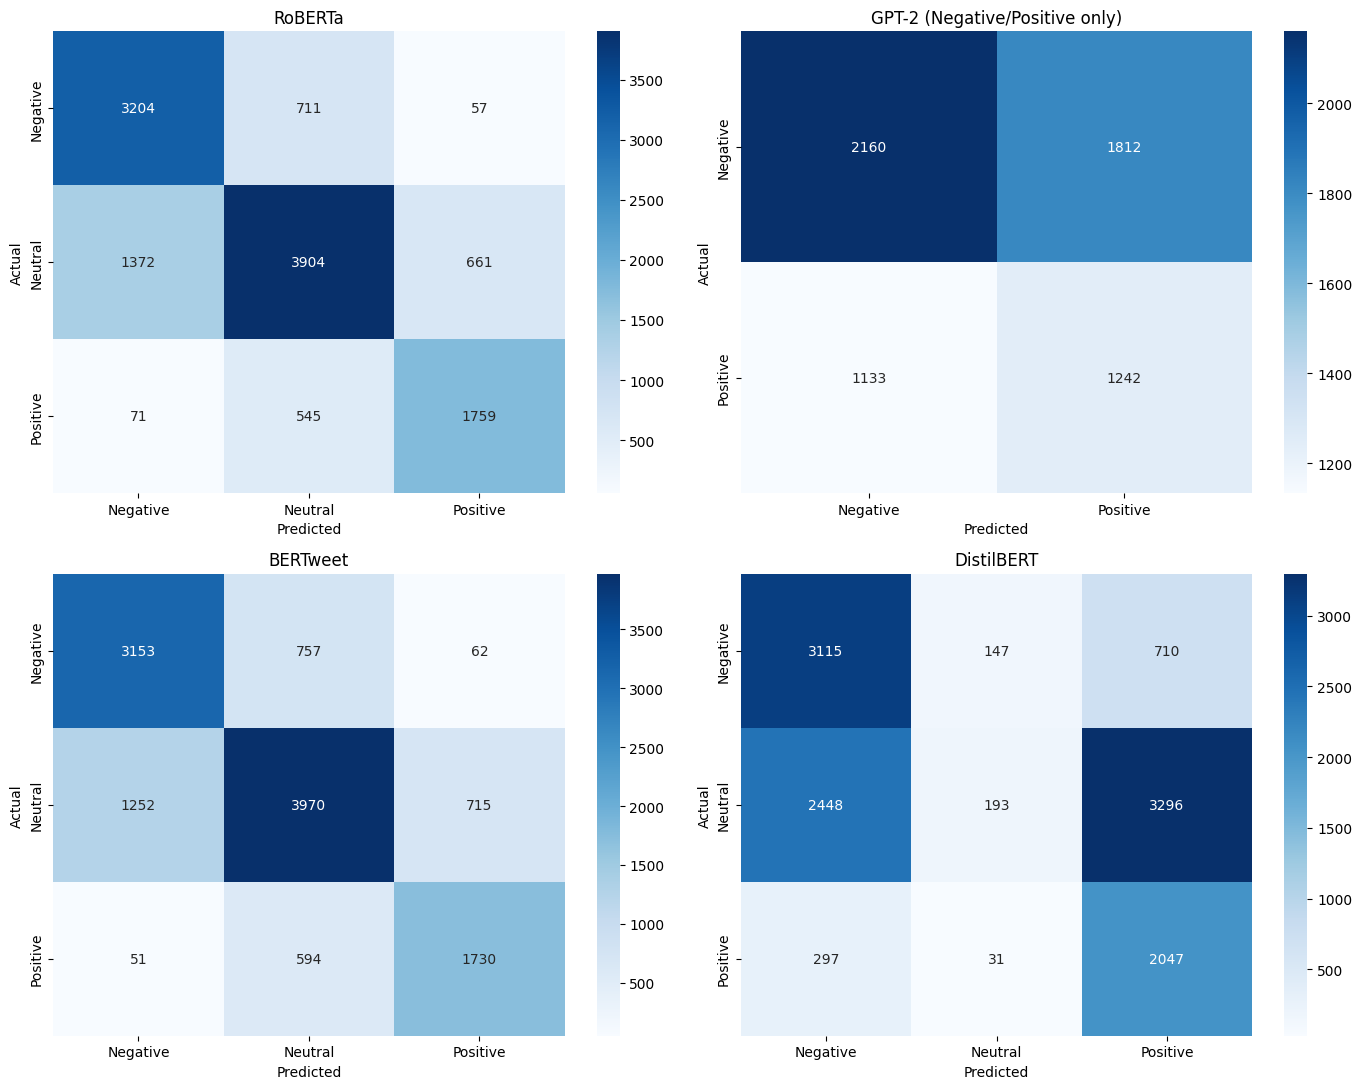

In [21]:
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score, confusion_matrix

label_ids = [0, 1, 2]
label_names = ["Negative", "Neutral", "Positive"]

def evaluate_model(model_name, y_true, y_pred, prediction_time=np.nan, supported_labels=None):
  if supported_labels is None:
    supported_labels = label_ids

  y_true = np.asarray(y_true)
  y_pred = np.asarray(y_pred)

  if len(y_true) != len(y_pred):
    raise ValueError(f"{model_name}: y_true and y_pred lengths differ ({len(y_true)} != {len(y_pred)}).")

  precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=supported_labels, zero_division=0
  )

  precision_by_label = dict(zip(supported_labels, precision))
  recall_by_label = dict(zip(supported_labels, recall))
  f1_by_label = dict(zip(supported_labels, f1))

  valid_time = prediction_time is not None and np.isfinite(prediction_time) and prediction_time > 0

  result = {
    "Model": model_name,
    "Evaluation Scope": "Negative + Neutral + Positive" if 1 in supported_labels else "Negative + Positive only",
    "Number of Examples": len(y_true),
    "Accuracy": accuracy_score(y_true, y_pred),
    "Macro F1": f1_score(y_true, y_pred, labels=supported_labels, average="macro", zero_division=0),
    "Negative F1": f1_by_label.get(0, np.nan),
    "Neutral F1": f1_by_label.get(1, np.nan),
    "Positive F1": f1_by_label.get(2, np.nan),
    "Negative Precision": precision_by_label.get(0, np.nan),
    "Neutral Precision": precision_by_label.get(1, np.nan),
    "Positive Precision": precision_by_label.get(2, np.nan),
    "Negative Recall": recall_by_label.get(0, np.nan),
    "Neutral Recall": recall_by_label.get(1, np.nan),
    "Positive Recall": recall_by_label.get(2, np.nan),
    "Total prediction time (seconds)": prediction_time if valid_time else np.nan,
    "Available examples per second": len(y_true) / prediction_time if valid_time else np.nan,
    "Avg time cost per example (milliseconds)": prediction_time * 1000 / len(y_true) if valid_time else np.nan
  }

  cm = confusion_matrix(y_true, y_pred, labels=label_ids)
  return result, cm

true_labels = test_df["label"].to_numpy()
binary_mask = true_labels != 1
true_labels_gpt2 = true_labels[binary_mask]
predictions_gpt2_common = np.where(np.asarray(predictions_gpt2) == 0, 0, 2)

prediction_times = {
  "RoBERTa": globals().get("prediction_time_twitter", np.nan),
  "GPT-2": globals().get("prediction_time_gpt2", np.nan),
  "BERTweet": globals().get("prediction_time_bertweet", np.nan),
  "DistilBERT": globals().get("prediction_time_distilbert", np.nan)
}

roberta_result, roberta_cm = evaluate_model(
  "RoBERTa", true_labels, predictions_twitter, prediction_times["RoBERTa"]
)

gpt2_result, gpt2_cm = evaluate_model(
  "GPT-2", true_labels_gpt2, predictions_gpt2_common, prediction_times["GPT-2"], supported_labels=[0, 2]
)

bertweet_result, bertweet_cm = evaluate_model(
  "BERTweet", true_labels, predictions_bertweet, prediction_times["BERTweet"]
)

distilbert_result, distilbert_cm = evaluate_model(
  "DistilBERT", true_labels, predictions_distilbert, prediction_times["DistilBERT"]
)

evaluation_results = pd.DataFrame([
  roberta_result, gpt2_result, bertweet_result, distilbert_result
])

numeric_columns = evaluation_results.select_dtypes(include=[np.number]).columns
evaluation_results[numeric_columns] = evaluation_results[numeric_columns].round(4)
display(evaluation_results)

confusion_matrices = {
  "RoBERTa": (roberta_cm, ["Negative", "Neutral", "Positive"]),
  "GPT-2 (Negative/Positive only)": (gpt2_cm[np.ix_([0, 2], [0, 2])], ["Negative", "Positive"]),
  "BERTweet": (bertweet_cm, ["Negative", "Neutral", "Positive"]),
  "DistilBERT": (distilbert_cm, ["Negative", "Neutral", "Positive"])
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, (model_name, (cm, cm_labels)) in zip(axes.flatten(), confusion_matrices.items()):
  sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=cm_labels,
    yticklabels=cm_labels,
    ax=ax
  )

  ax.set_title(model_name)
  ax.set_xlabel("Predicted")
  ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

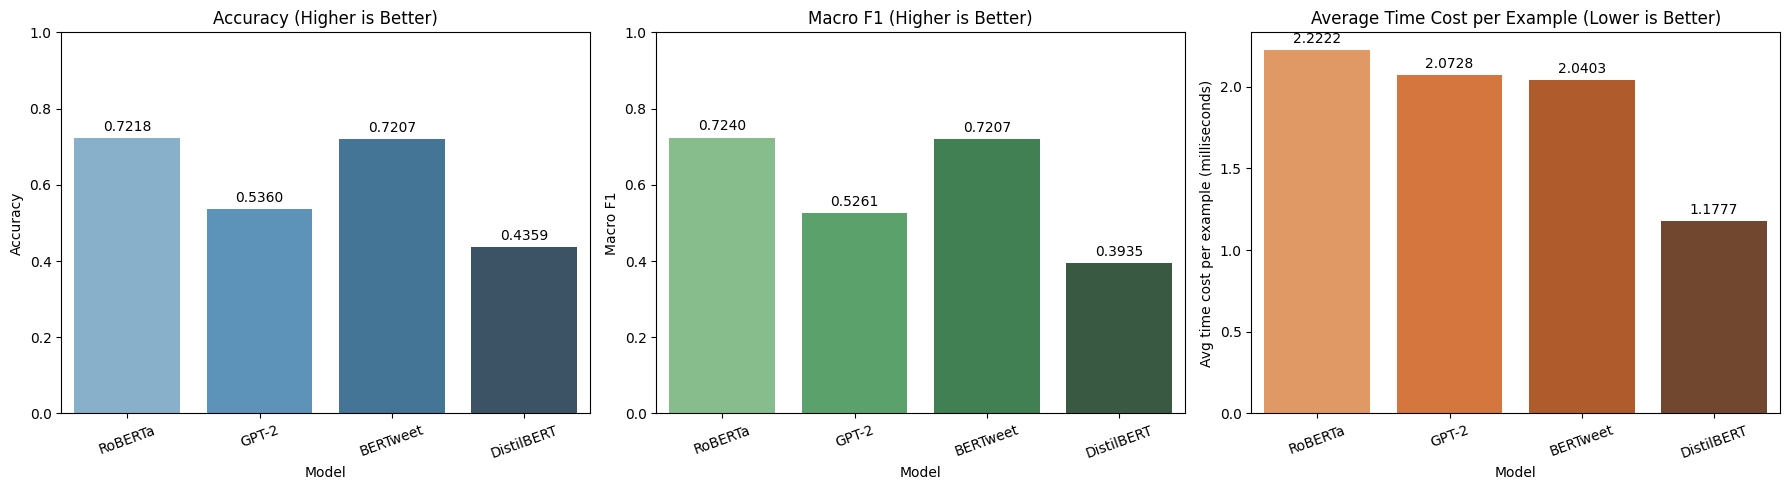

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=evaluation_results, x="Model", y="Accuracy", hue="Model", legend=False, ax=axes[0], palette="Blues_d")
axes[0].set_title("Accuracy (Higher is Better)")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

sns.barplot(data=evaluation_results, x="Model", y="Macro F1", hue="Model", legend=False, ax=axes[1], palette="Greens_d")
axes[1].set_title("Macro F1 (Higher is Better)")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0, 1)

sns.barplot(data=evaluation_results, x="Model", y="Avg time cost per example (milliseconds)", hue="Model", legend=False, ax=axes[2], palette="Oranges_d")
axes[2].set_title("Average Time Cost per Example (Lower is Better)")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("Avg time cost per example (milliseconds)")

for ax in axes:
  ax.tick_params(axis="x", rotation=20)
  for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.tight_layout()
plt.show()

In [23]:
import wandb
import numpy as np
import pandas as pd

# 1. Prepare the evaluation dataframe with all predictions aligned
eval_df = test_df.copy()

# Feature Engineering
eval_df["word_count"] = eval_df["text"].str.split().str.len()
eval_df["has_mention"] = eval_df["text"].str.contains("@user", regex=False)
eval_df["has_url"] = eval_df["text"].str.contains("http", case=False, regex=False)
eval_df["has_hashtag"] = eval_df["text"].str.contains("#", regex=False)
eval_df["is_negative_class"] = eval_df["label"] == 0

# Align predictions to the full 12,284 rows
eval_df["roberta_pred"] = predictions_twitter
eval_df["bertweet_pred"] = predictions_bertweet
eval_df["distilbert_pred"] = predictions_distilbert

# GPT-2 only predicted on Negative/Positive classes, so we use a mask
eval_df["gpt2_pred"] = np.nan
binary_mask = eval_df["label"] != 1
eval_df.loc[binary_mask, "gpt2_pred"] = predictions_gpt2_common

# Define the models, referencing the new aligned columns instead of raw arrays
models_data = [
    {
        "model_name": "twitter-roberta-base",
        "pred_column": "roberta_pred",
        "metrics": roberta_result
    },
    {
        "model_name": "gpt2-finetuned",
        "pred_column": "gpt2_pred",
        "metrics": gpt2_result
    },
    {
        "model_name": "bertweet-base",
        "pred_column": "bertweet_pred",
        "metrics": bertweet_result
    },
    {
        "model_name": "distilbert-base",
        "pred_column": "distilbert_pred",
        "metrics": distilbert_result
    }
]

# Using floats because np.nan casts the pandas column type to float64
label_map = {0.0: "Negative", 1.0: "Neutral", 2.0: "Positive"}

# Loop through each model and log a separate run
for model in models_data:

    run = wandb.init(
        project="customer-complaint-monitoring",
        name=f"{model['model_name']}-eval",
        job_type="evaluation",
        config={
            "model_name": model["model_name"],
            "max_length": 128,
            "dataset": "tweet_eval"
        }
    )

    table = wandb.Table(columns=[
        "original_text",
        "ground_truth_label",
        "model_prediction",
        "word_count",
        "has_mention",
        "has_url",
        "has_hashtag",
        "is_negative_class"
    ])

    for index, row in eval_df.iterrows():
        pred_val = row[model["pred_column"]]

        # Map valid predictions, and label the skipped GPT-2 neutral tweets as "Not evaluated"
        pred_str = label_map.get(pred_val, "Not evaluated") if pd.notna(pred_val) else "Not evaluated"

        table.add_data(
            row["original_text"],
            row["sentiment"],
            pred_str,
            row["word_count"],
            row["has_mention"],
            row["has_url"],
            row["has_hashtag"],
            row["is_negative_class"]
        )

    run.log({
        "eval_results_table": table,
        "eval/f1": model["metrics"]["Macro F1"],
        "eval/accuracy": model["metrics"]["Accuracy"]
    })

    run.finish()

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: yongjun-k (yongjun-k-khon-kaen-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


eval/accuracy,▁
eval/f1,▁
eval/accuracy,0.72183
eval/f1,0.72405


eval/accuracy,▁
eval/f1,▁
eval/accuracy,0.536
eval/f1,0.52609


eval/accuracy,▁
eval/f1,▁
eval/accuracy,0.72069
eval/f1,0.72074


eval/accuracy,▁
eval/f1,▁
eval/accuracy,0.43593
eval/f1,0.39353
